# Granite based on global sensitivity behavior for joint feature influence using the Diabetes dataset

This notebook leverages GRANITE to yield regional explanations for joined feature influence of feature groups on the Diabetes dataset using global behavior based on sensitivity. We focus here on minimizing disagreement due to interactions (pure vs. full).

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV, train_test_split
from sklearn.metrics import root_mean_squared_error
from joblib import dump, load
import pathlib

# Local imports
from granite.data import get_data_diabetes
from granite.decompositions import get_components_brute_force, get_regional_decompositions
import numpy as np
import matplotlib.pyplot as plt

from granite.features import Features
from granite.fd_trees import FDTree
from granite.plots import bar, overlay_bars
from granite.decompositions import get_components_brute_force, get_regional_decompositions

### Input Features

The Diabetes dataset aims to predict disease progression one year after baseline based on 10 numerical features: age, sex, bmi, bp and six serum measurements. It involves 442 instances.

First load the data and a `Features` object that stores information about the various features.
Note that the data **X** must **always** be a numerical numpy array. Categorical features are assumed
to have been ordinally encoded.

In [2]:
# Built-in function for the BikeSharing dataset
X, y, features = get_data_diabetes()
print(X.shape)
features.summary()



(442, 10)
|Idx|        Name        |        Type        |    Card    |      Groups      |
-------------------------------------------------------------------------------
| 0 | age                | num                | inf        | [0]              |
| 1 | sex                | num                | inf        | [1]              |
| 2 | bmi                | num                | inf        | [2]              |
| 3 | bp                 | num                | inf        | [3]              |
| 4 | s1                 | num                | inf        | [4]              |
| 5 | s2                 | num                | inf        | [5]              |
| 6 | s3                 | num                | inf        | [6]              |
| 7 | s4                 | num                | inf        | [7]              |
| 8 | s5                 | num                | inf        | [8]              |
| 9 | s6                 | num                | inf        | [9]              |
------------------------------

### Fitting the model
Having fetched the data, we fit a `HistGradientBoostingRegressor`.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = HistGradientBoostingRegressor(random_state=0)

In [4]:
grid = {"learning_rate": np.logspace(-2, 0, 10),
        "max_depth" : [3, 4, 5, 6, 7],
        "max_iter" : [50, 100, 150, 200],
        'min_samples_leaf' : [1, 20, 40, 60, 80, 100]}

search = RandomizedSearchCV(
    model,
    cv=KFold(),
    scoring='neg_root_mean_squared_error',
    param_distributions=grid,
    verbose=2,
    n_iter=20,
    random_state=42
)
search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END learning_rate=1.0, max_depth=7, max_iter=50, min_samples_leaf=40; total time=   0.1s
[CV] END learning_rate=1.0, max_depth=7, max_iter=50, min_samples_leaf=40; total time=   0.0s
[CV] END learning_rate=1.0, max_depth=7, max_iter=50, min_samples_leaf=40; total time=   0.1s
[CV] END learning_rate=1.0, max_depth=7, max_iter=50, min_samples_leaf=40; total time=   0.0s
[CV] END learning_rate=1.0, max_depth=7, max_iter=50, min_samples_leaf=40; total time=   0.0s
[CV] END learning_rate=0.3593813663804626, max_depth=4, max_iter=50, min_samples_leaf=20; total time=   0.1s
[CV] END learning_rate=0.3593813663804626, max_depth=4, max_iter=50, min_samples_leaf=20; total time=   0.1s
[CV] END learning_rate=0.3593813663804626, max_depth=4, max_iter=50, min_samples_leaf=20; total time=   0.1s
[CV] END learning_rate=0.3593813663804626, max_depth=4, max_iter=50, min_samples_leaf=20; total time=   0.1s
[CV] END learning_rate=0.3593813

,estimator,HistGradientB...andom_state=0)
,param_distributions,"{'learning_rate': array([0.01 ..., 1. ]), 'max_depth': [3, 4, ...], 'max_iter': [50, 100, ...], 'min_samples_leaf': [1, 20, ...]}"
,n_iter,20
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,KFold(n_split...shuffle=False)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [5]:
# Recover the optimal CV model
model = search.best_estimator_
res = search.cv_results_
cv_perf = np.nan_to_num(-res['mean_test_score'], nan=1e10)
best_idx = np.argmin(cv_perf)

## Pure and Full Joint Sobol Effects (Global Sensitivity Marginal)

Here, we define feature groups which are possible in a meaningful way for the diabetes dataset by grouping demographic, body metrics and lab markers together as shown below. Then we apply GRANITE to minimize interactions between these groups.

In [6]:

grouped_features = features.group([[0, 1], [2, 3], [4, 5, 6, 7, 8, 9]])
grouped_features.summary()

|Idx|        Name        |        Type        |    Card    |      Groups      |
-------------------------------------------------------------------------------
| 0 | age:sex            | num:num            | inf:inf    | [0, 1]           |
| 1 | bmi:bp             | num:num            | inf:inf    | [2, 3]           |
| 2 | s1:s2:s3:s4:s5:s6  | num:num:num:num:num| inf:inf:inf| [4, 5, 6, 7, 8, 9|
-------------------------------------------------------------------------------



In [9]:
# The decomposition is computed as always, while passing the `grouped_features` object instead of `features`
#grouped_decomposition = get_components_brute_force(model, X, X, grouped_features)
#display(grouped_decomposition.keys())

from granite.decompositions import get_components_tree

#decomposition = get_components_brute_force(model, background, background, features=features, anchored=True)
decomposition = get_components_tree(model, X, X, features=grouped_features, anchored=True)

[#############################################     ] 91%

#####] 100%

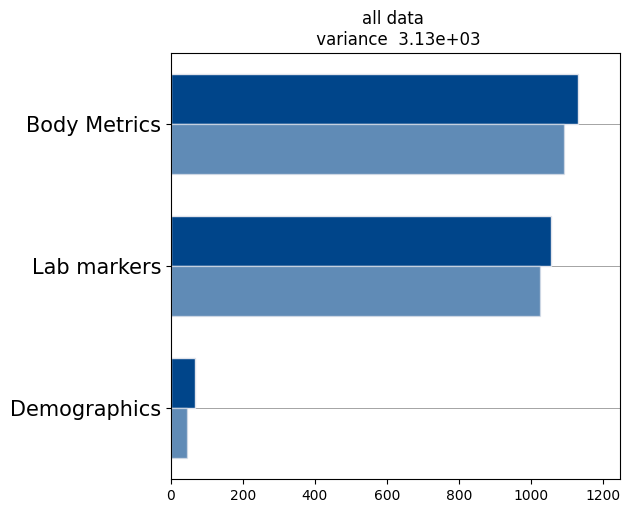

In [44]:
from granite.experiments import get_closed_total_sobol
grouped_feature_names = ["Demographics",  "Body Metrics", "Lab markers"]
#order_features = list(reversed([0, 1, 2]))
#order_features = list(reversed([0, 2, 1]))
#order_features = list(reversed([1, 0, 2]))
order_features = list(reversed([1, 2, 0]))
#order_features = list(reversed([2, 0, 1]))
#order_features = list(reversed([2, 1, 0]))
H_tensor = np.stack([decomposition[(i,)] for i in range(len(grouped_features))], axis=-1)
closed_sobol_all_data, total_sobol_all_data = get_closed_total_sobol(H_tensor)

bar([total_sobol_all_data, closed_sobol_all_data], grouped_feature_names, ordered_features=order_features)
#plt.xlim(0, 25000)
plt.title(f"all data \n variance {decomposition[()].var(): .2e}")
# Save plot
plt.savefig(f"../figures/diabetes_sensitivity_pure_full_global.pdf", bbox_inches="tight")
plt.show()

In [13]:
from granite.experiments import get_marginal_pure_vs_full_variance_loss_fn

marginal_pure_vs_full_loss_fn = get_marginal_pure_vs_full_variance_loss_fn(
    decomposition=decomposition,
    U=[(i,) for i in range(len(grouped_features))]
)

tree = FDTree(features, max_depth=2, save_losses=True, branching_per_node=3)
tree.fit(X, loss_fn=marginal_pure_vs_full_loss_fn)
tree.print(verbose=True)


Loss 1.0000
Samples 442
If bmi ≤ 0.0052:
|   Loss 0.2037
|   Samples 265
|   If bp ≤ 0.0219:
|   |   Loss 0.0355
|   |   Samples 213
|   |   Region 0
|   else:
|   |   Loss 0.0081
|   |   Samples 52
|   |   Region 1
else:
|   Loss 0.3234
|   Samples 177
|   If sex ≤ -0.0446:
|   |   Loss 0.0970
|   |   Samples 94
|   |   Region 2
|   else:
|   |   Loss 0.0502
|   |   Samples 83
|   |   Region 3
Final Loss 0.1909


In [14]:
# Use the tree to compute regional decompositions

regions = tree.predict(X)
print(regions[:10])
n_regions = tree.n_regions
rules = tree.rules()
print(rules)
_, counts = np.unique(regions, return_counts=True)
print(counts)

[3 0 3 0 0 0 0 1 3 2]
{0: '(bmi<=0.01 & bp<=0.02)', 1: '(bmi<=0.01 & bp>0.02)', 2: '(bmi>0.01 & sex<=-0.04)', 3: '(bmi>0.01 & sex>-0.04)'}
[213  52  94  83]


In [15]:
#regional_decompositions = get_regional_decompositions(decomposition, regions, regions, n_regions)
# We compute regional decompositions
regional_backgrounds = [[]] * tree.n_regions
regional_decomposition = [[]] * tree.n_regions
for r in range(tree.n_regions):
    regional_backgrounds[r] = X[regions == r]
    # Regional Decomposition
    regional_decomposition[r] = get_components_tree(model,
                                                    regional_backgrounds[r],
                                                    regional_backgrounds[r],
                                                    grouped_features,
                                                    anchored=True
                                                    )

[##################################################] 100%[                       #########################] 100%[###### ###### ###### ############################] 100%[####### ## ####### ## ########## ## ####### ## ##] 100%

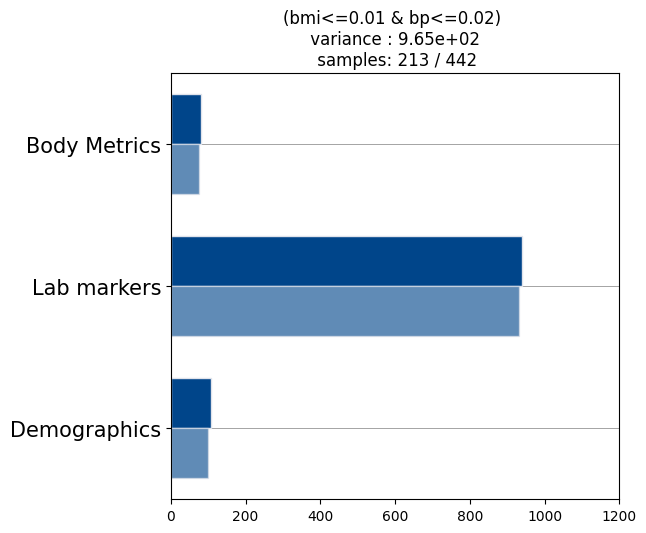

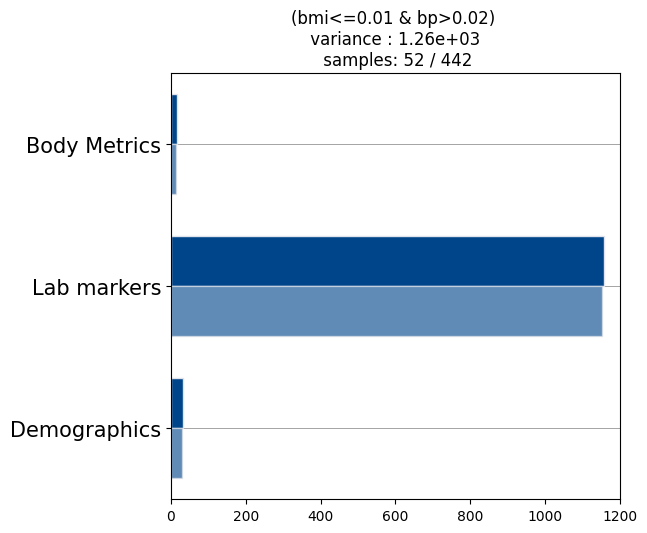

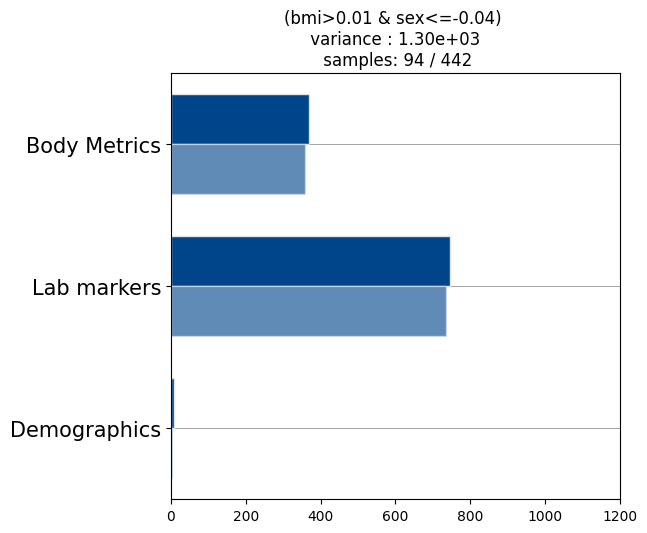

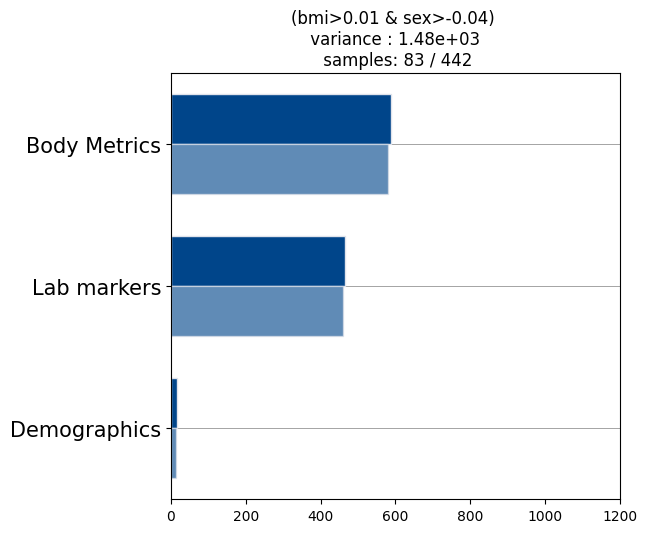

In [45]:
for r in range(tree.n_regions):
    H_tensor = np.stack([regional_decomposition[r][(i,)] for i in range(len(grouped_features))], axis=-1)
    closed_sobol, total_sobol = get_closed_total_sobol(H_tensor)
    bar_plot_data.append({"closed_sobol": closed_sobol, "total_sobol": total_sobol})

    bar([total_sobol, closed_sobol], grouped_feature_names, ordered_features=order_features)
    plt.xlim(0, 1200)
    plt.title(f"{rules[r]} \n variance : {regional_decomposition[r][()].var():.2e} \n samples: {counts[r]} / {len(X)}")
    # Save plot
    plt.savefig(f"../figures/diabetes_sensitivity_full_pure_region_{r}.pdf", bbox_inches="tight")
    plt.show()

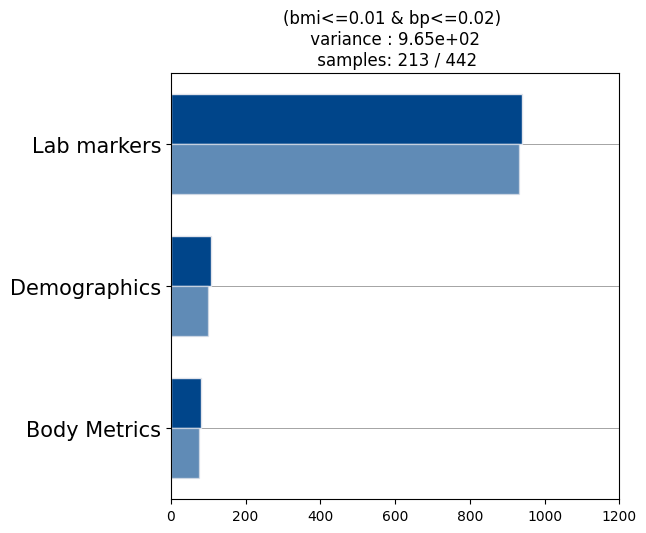

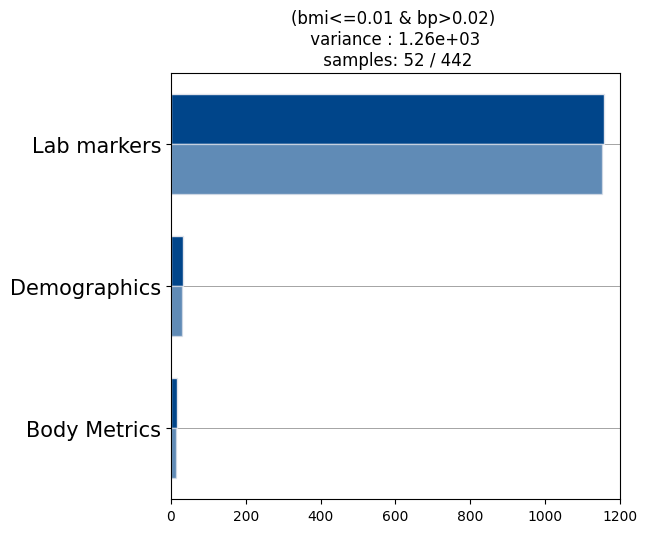

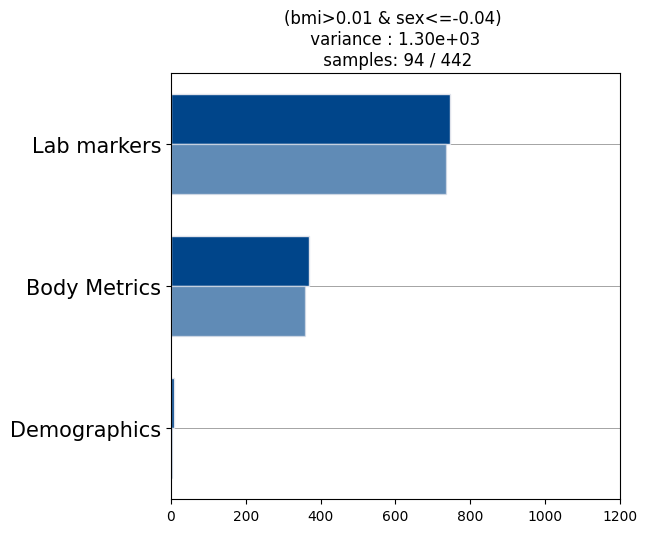

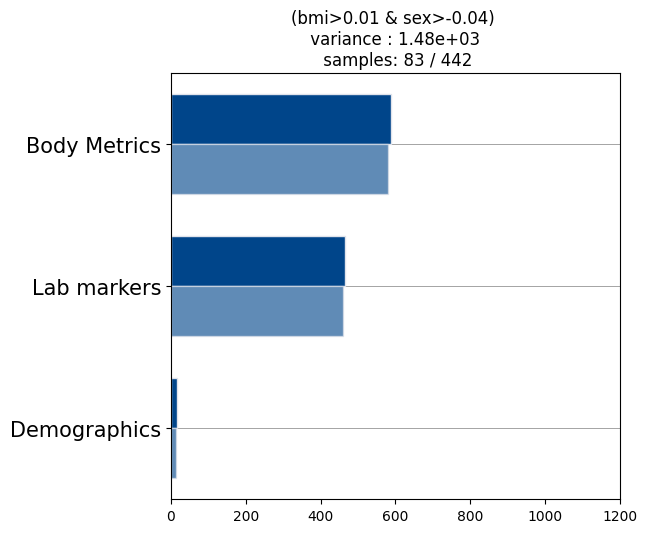

In [23]:
# Define fixed feature order (index -> name mapping)
feature_order = [
    (0, "Demographics"),
    (1, "Body Metrics"),
    (2, "Lab markers"),
]

bar_plot_data = []
for r in range(tree.n_regions):
    # Stack decomposition in exactly this order
    H_tensor = np.stack([regional_decomposition[r][(i,)] for i, _ in feature_order], axis=-1)
    closed_sobol, total_sobol = get_closed_total_sobol(H_tensor)

    bar_plot_data.append({"closed_sobol": closed_sobol, "total_sobol": total_sobol})

    # Use the names from the same list
    labels = [name for _, name in feature_order]
    bar([total_sobol, closed_sobol], labels)

    plt.xlim(0, 1200)
    plt.title(
        f"{rules[r]} \n variance : {regional_decomposition[r][()].var():.2e} \n samples: {counts[r]} / {len(X)}"
    )
    plt.show()
